In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
import pandas as pd

df = pd.read_csv("/workspaces/Proyecto_Final/data/processed/vehicles_with_model_clean.csv")

df.head()

,price,year,manufacturer,model,fuel,odometer,transmission,drive,size,type,state,lat,long
0,22590,2010.0,chevrolet,silverado,gas,71229.0,other,4wd,full-size,pickup,al,32.5900,-85.480000
1,30990,2017.0,toyota,tundra,gas,41124.0,other,4wd,full-size,pickup,al,32.5900,-85.480000
2,15000,2013.0,ford,f150,gas,128000.0,automatic,rwd,full-size,truck,al,32.5920,-85.518900
3,35000,2019.0,toyota,tacoma,gas,43000.0,automatic,4wd,mid-size,truck,al,32.6013,-85.443974
4,29990,2016.0,chevrolet,colorado,gas,17302.0,other,4wd,mid-size,pickup,al,32.5900,-85.480000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301061 entries, 0 to 301060
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         301061 non-null  int64  
 1   year          301061 non-null  float64
 2   manufacturer  301061 non-null  object 
 3   model         301061 non-null  object 
 4   fuel          301061 non-null  object 
 5   odometer      301061 non-null  float64
 6   transmission  301061 non-null  object 
 7   drive         301061 non-null  object 
 8   size          301061 non-null  object 
 9   type          301061 non-null  object 
 10  state         301061 non-null  object 
 11  lat           301061 non-null  float64
 12  long          301061 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 29.9+ MB


In [5]:
df["price"].describe()

count    301061.000000
mean      15290.767997
std       14020.995365
min           0.000000
25%        5450.000000
50%       11200.000000
75%       21990.000000
max      195000.000000
Name: price, dtype: float64

In [6]:
# eliminar registros con precio 0

df = df[df["price"] > 1000]
df["price"].describe()

count    268289.000000
mean      17142.761638
std       13750.820479
min        1002.000000
25%        6995.000000
50%       12999.000000
75%       23885.000000
max      195000.000000
Name: price, dtype: float64

In [7]:
df = df[df["price"] < 75000]
df["price"].describe()

count    267217.000000
mean      16847.238881
std       12905.435102
min        1002.000000
25%        6995.000000
50%       12995.000000
75%       23500.000000
max       74999.000000
Name: price, dtype: float64

In [8]:

#separar las columnas numericas y categoricas y la columna objetivo

target = df["price"]
num_cols = ["year", "odometer", "lat", "long"]
cat_cols = ["manufacturer", "model", "fuel", "transmission", "drive", "size", "type", "state"]



In [9]:
#analizar las columnas numericas
df[num_cols].describe()

,year,odometer,lat,long
count,267217.000000,267217.000000,267217.000000,267217.000000
mean,2010.582815,101549.078651,38.632008,-94.391072
std,8.695698,57621.937541,5.957696,18.288569
min,1900.000000,0.000000,-81.838232,-159.719900
25%,2008.000000,55251.000000,35.052800,-110.864815
50%,2012.000000,100100.000000,39.433086,-88.240700
75%,2016.000000,142875.000000,42.472883,-80.787000
max,2022.000000,250000.000000,82.252826,167.629911


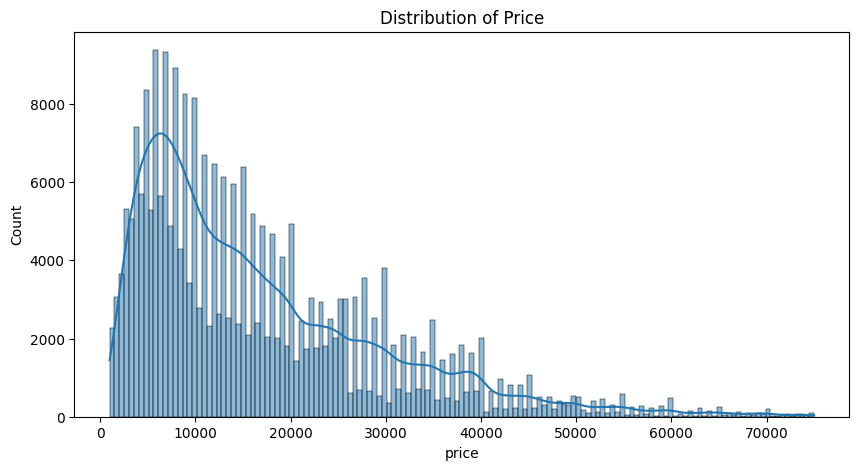

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
#visualizacion columna objetivo
plt.figure(figsize=(10, 5))
sns.histplot(target, kde=True)
plt.title('Distribution of Price')
plt.show()

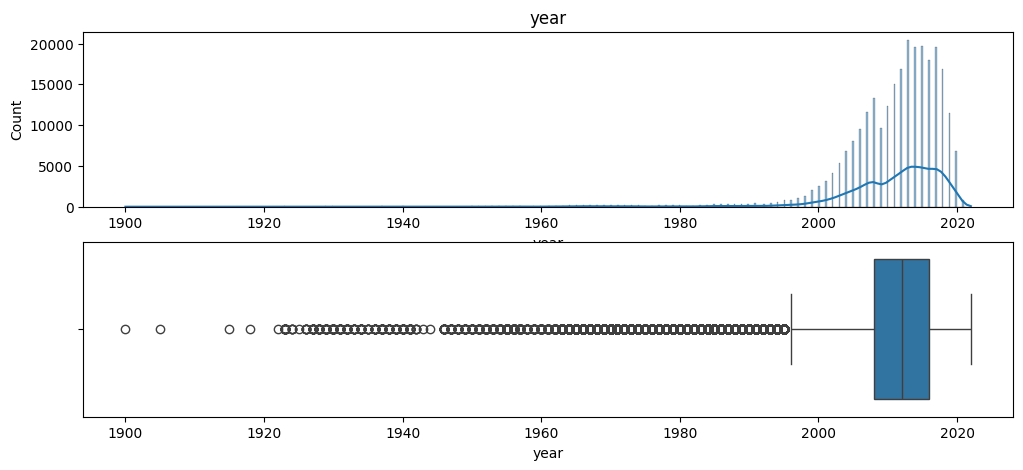

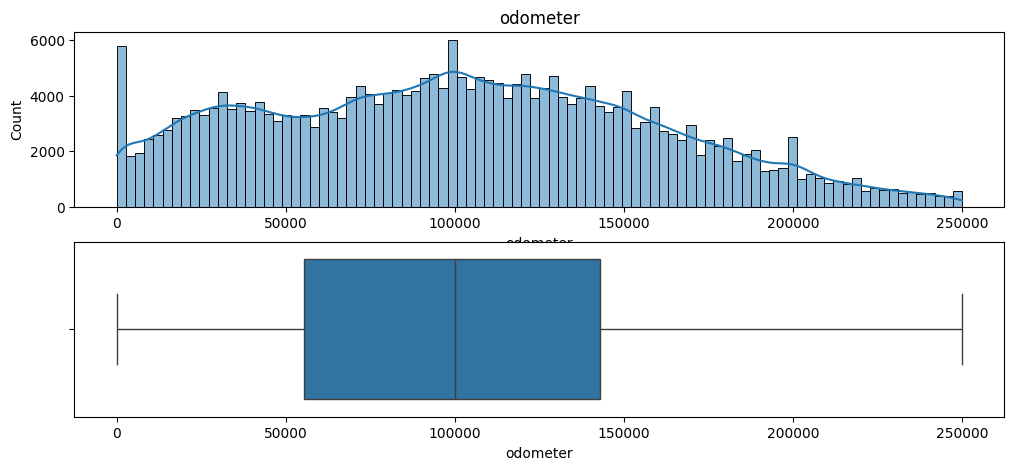

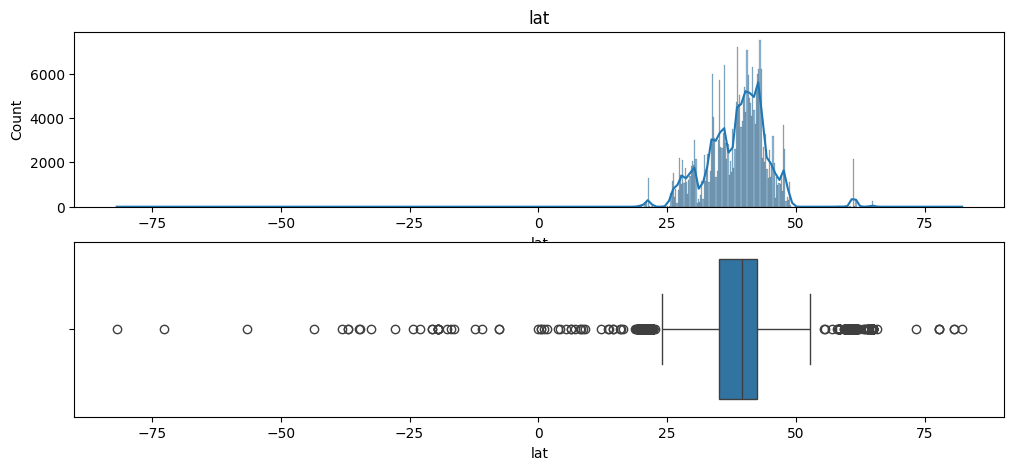

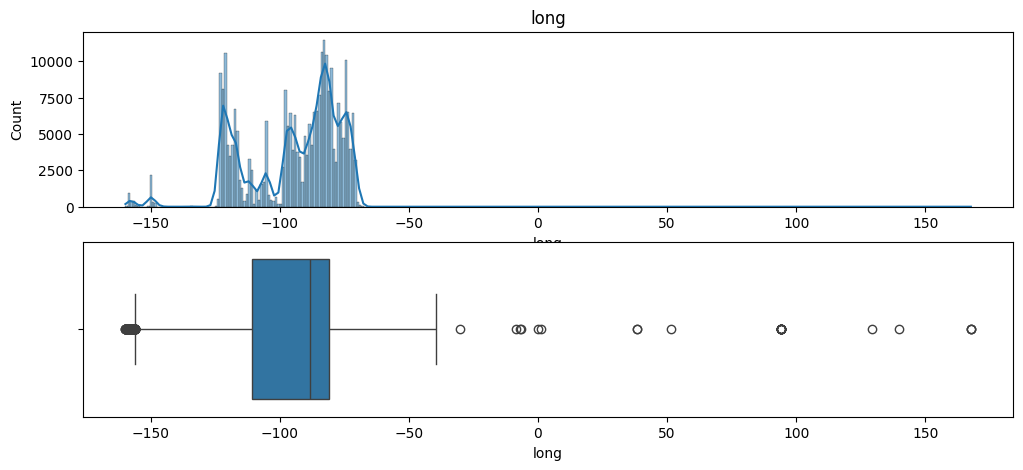

In [11]:

#visualizacion

for columna in num_cols:
    plt.figure(figsize=(12, 5))

    # Histograma
    plt.subplot(2, 1, 1)
    sns.histplot(df[columna], kde=True)
    plt.title(f'{columna}')

    # Boxplot
    plt.subplot(2, 1, 2)
    sns.boxplot(x=df[columna])

    plt.show()

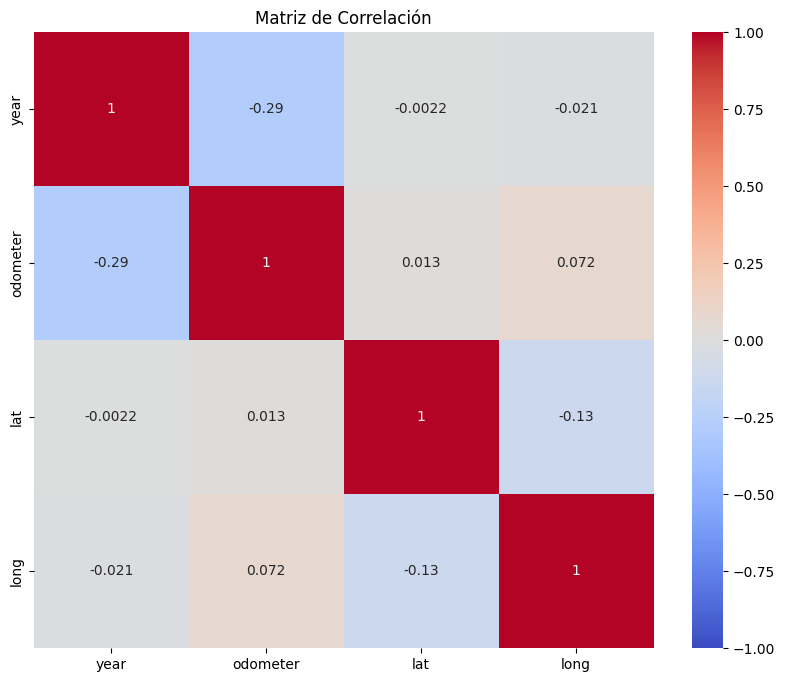

In [12]:
#matriz de correlacion
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

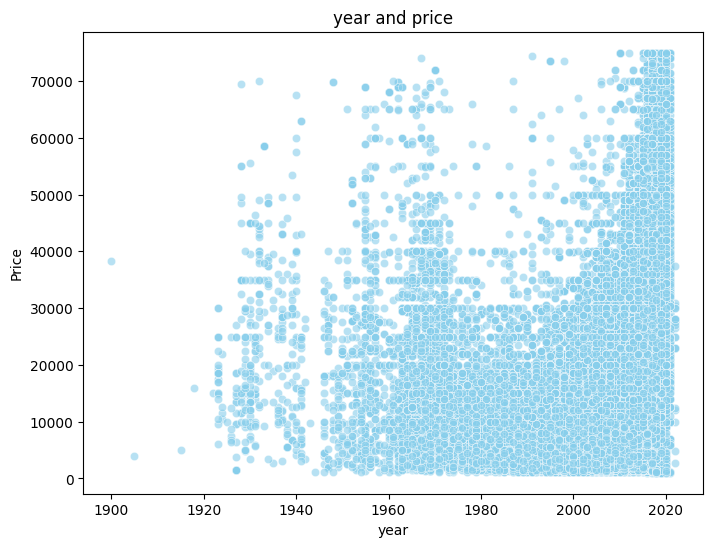

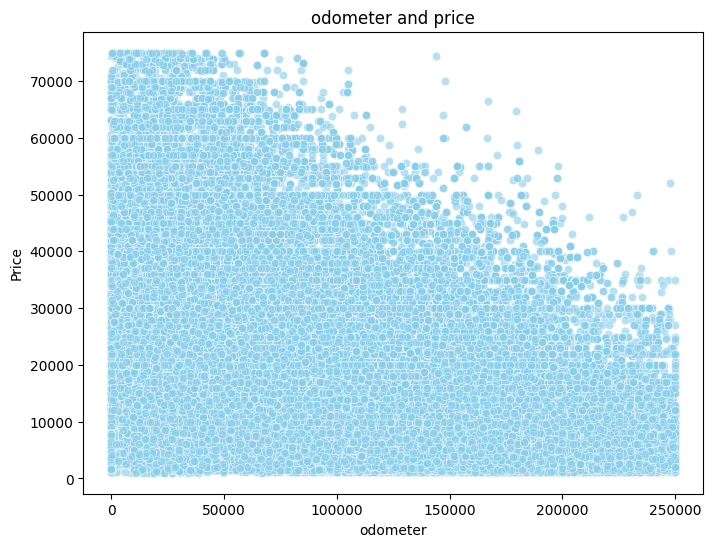

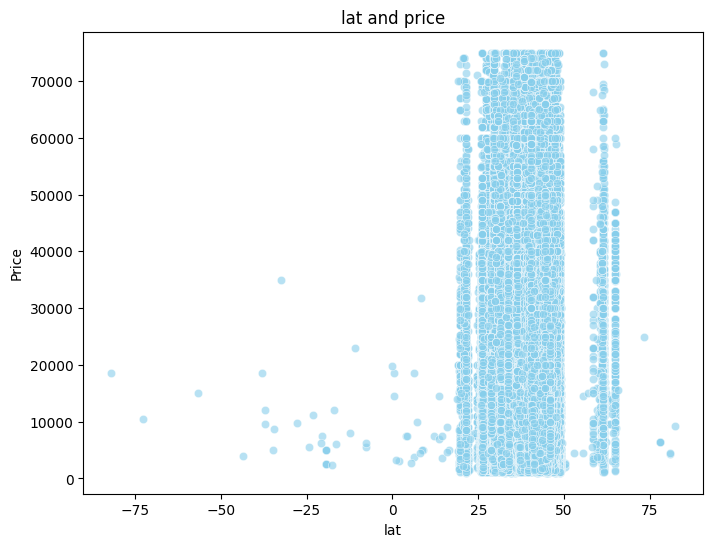

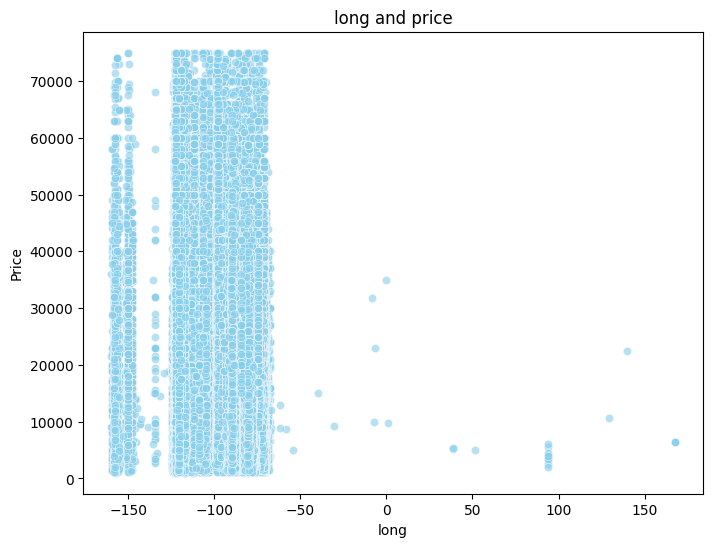

In [13]:
#analizar relacion entre columnas numericas y columna objetivo

for columna in num_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[columna], y= target, alpha=0.6, color="skyblue")
    plt.title(f'{columna} and price')
    plt.xlabel(columna)
    plt.ylabel("Price")
    plt.show() 

In [14]:
print(cat_cols)

['manufacturer', 'model', 'fuel', 'transmission', 'drive', 'size', 'type', 'state']


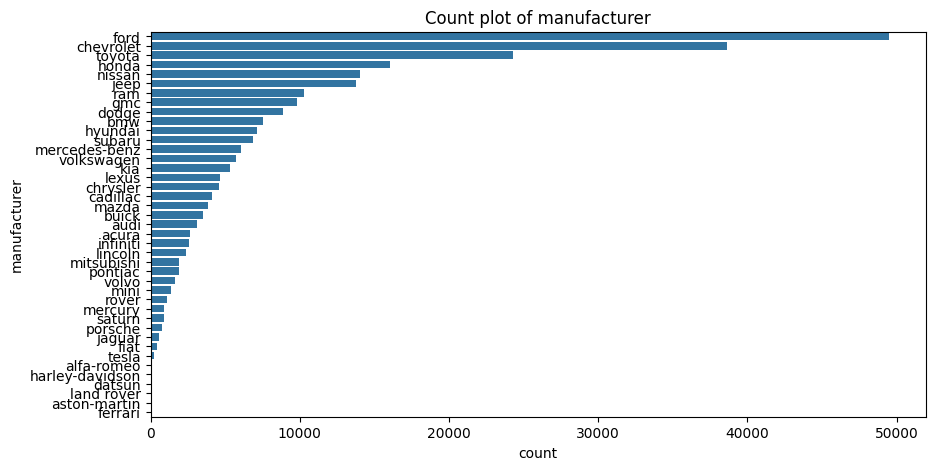

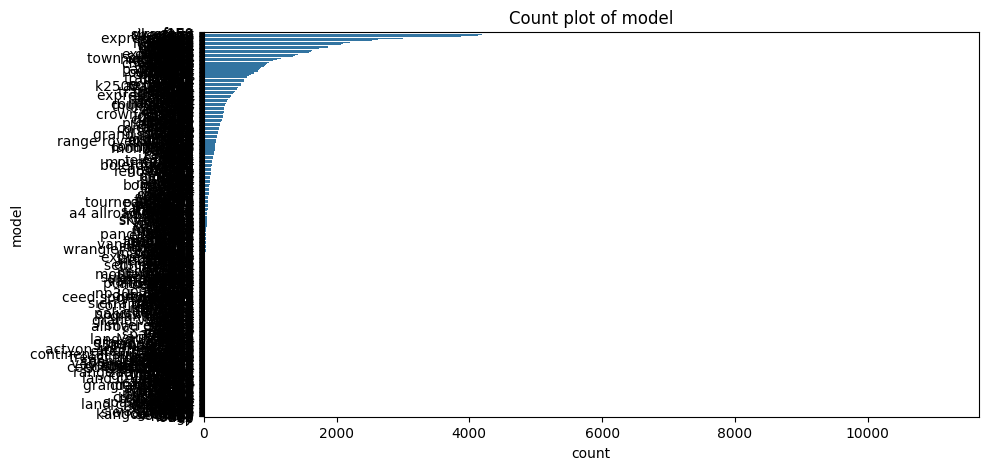

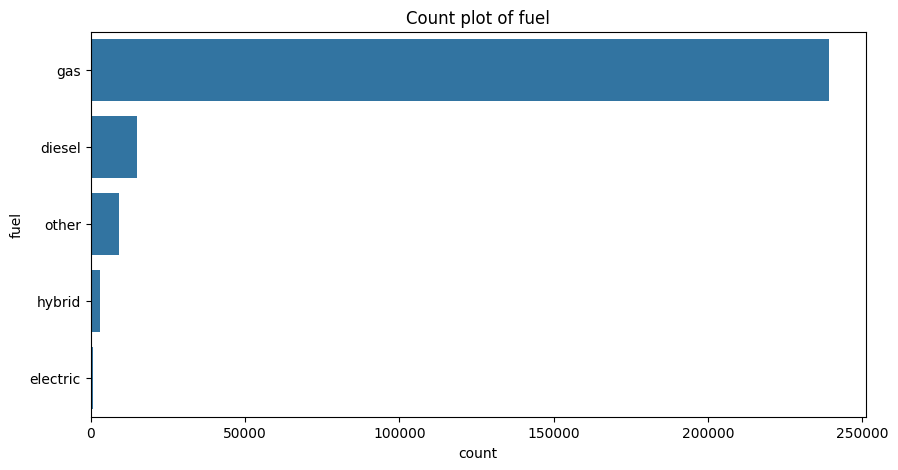

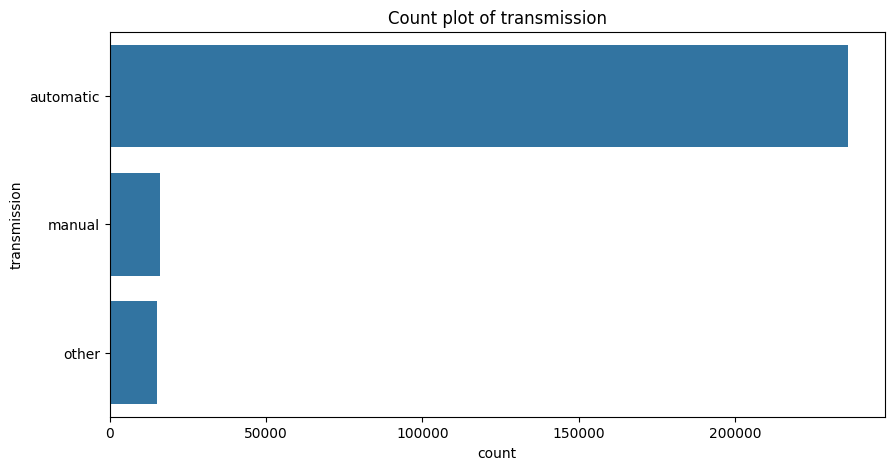

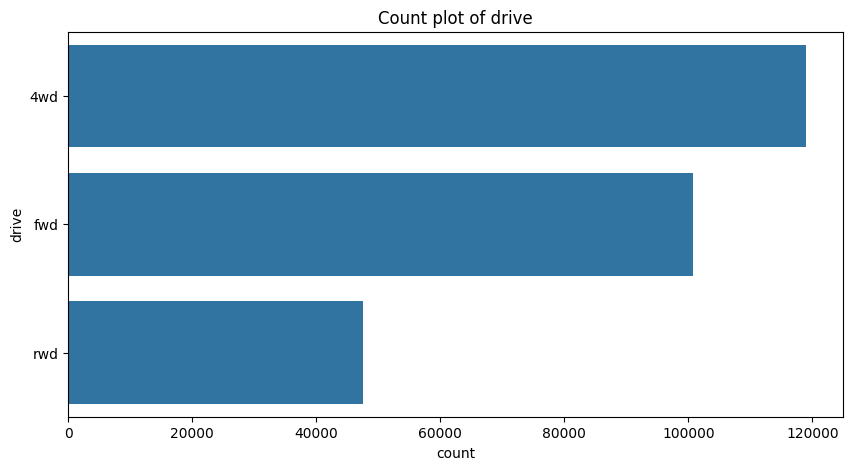

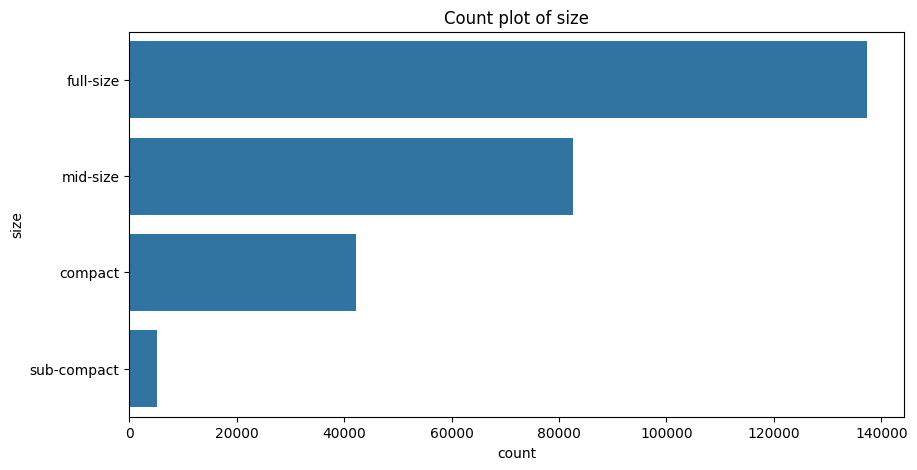

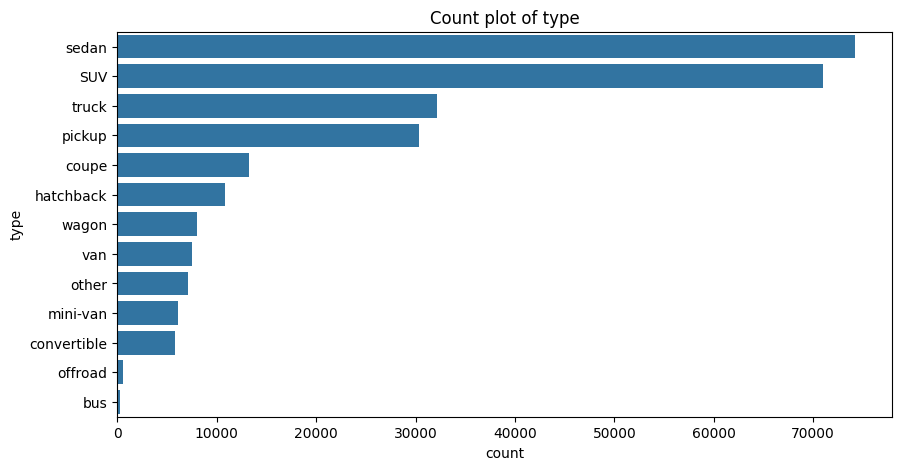

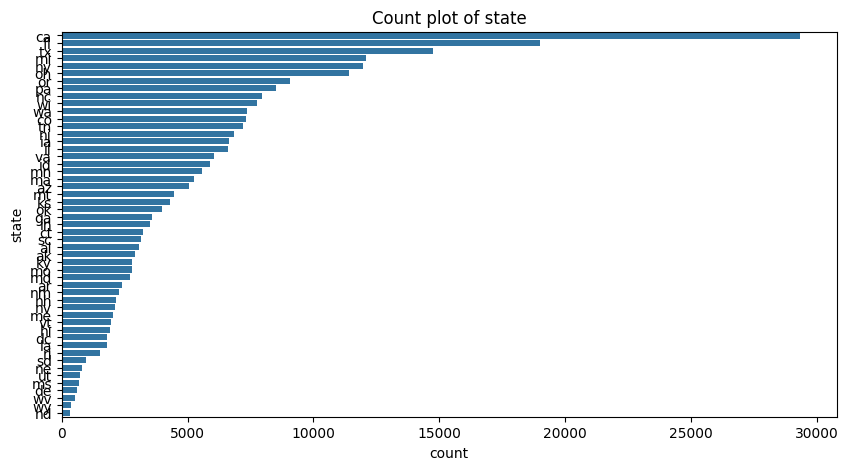

In [15]:
# Categorical Columns

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Count plot of {col}')
    plt.show()

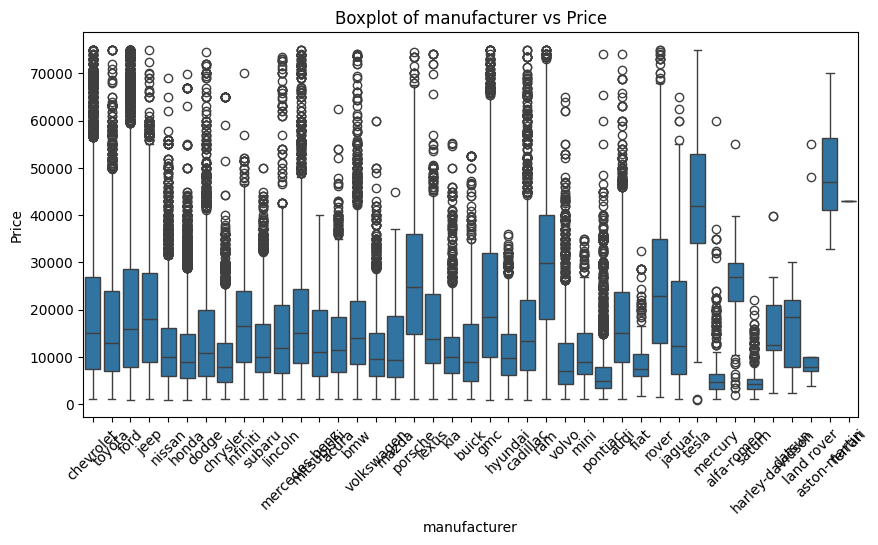

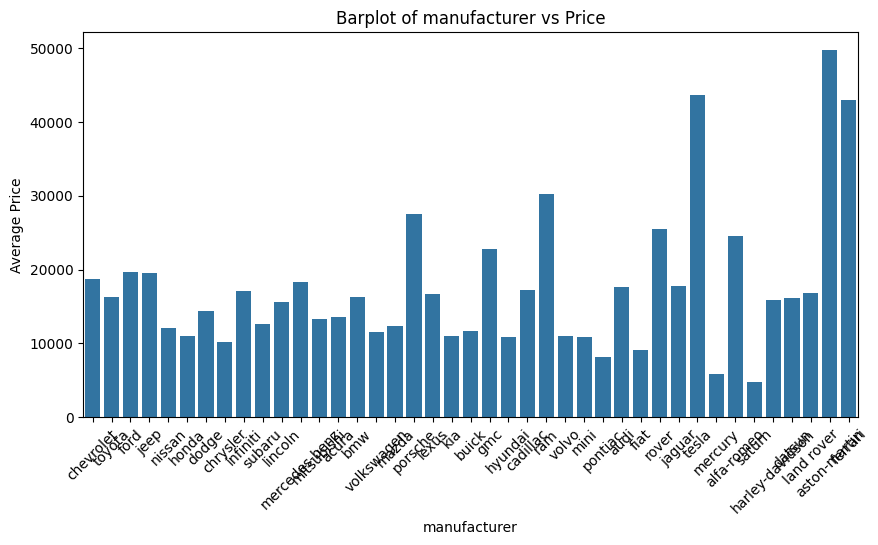

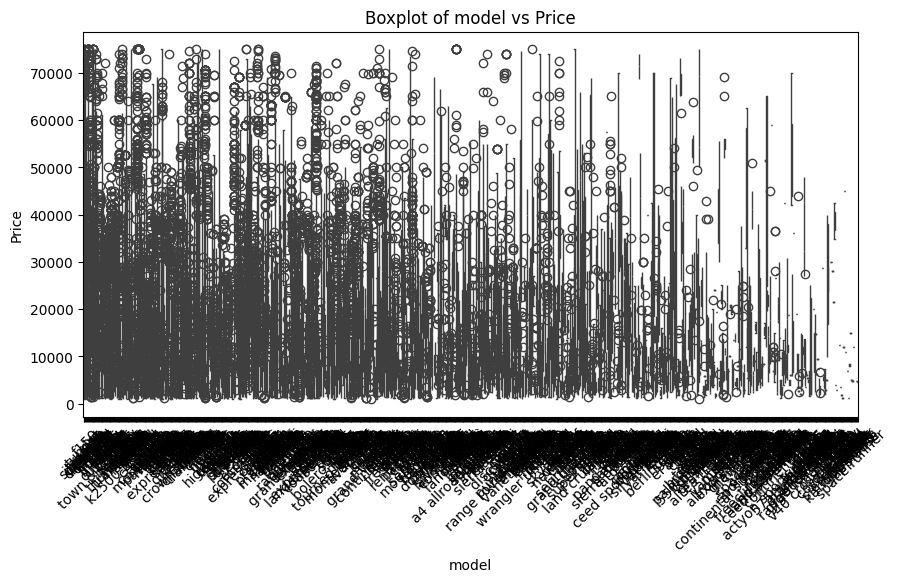

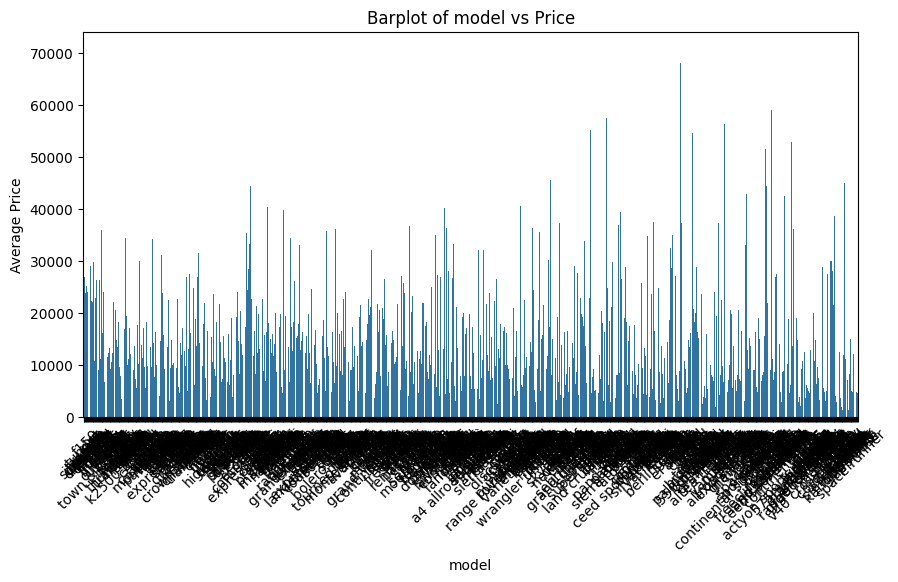

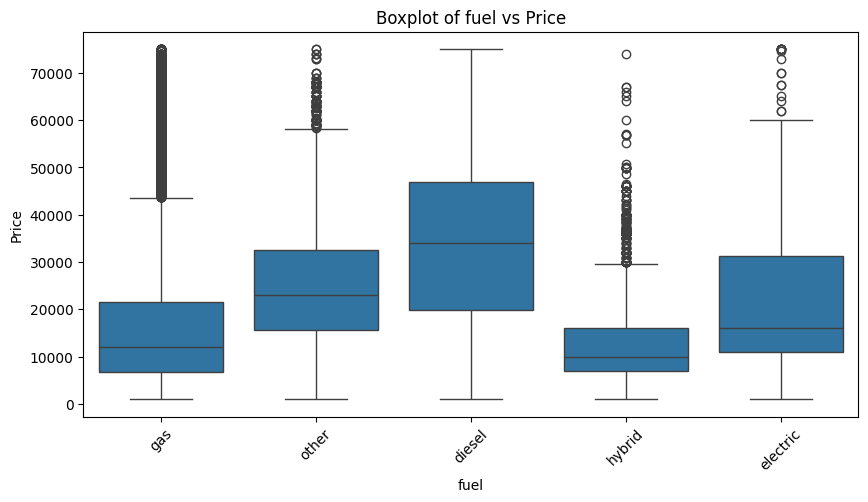

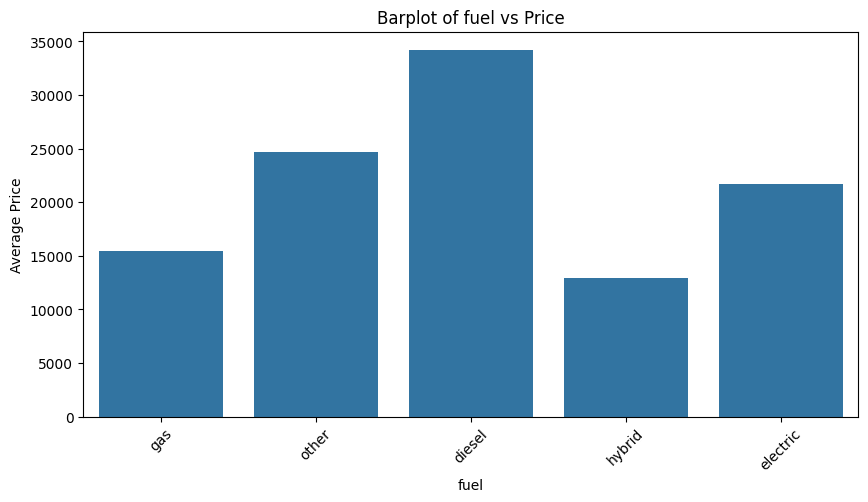

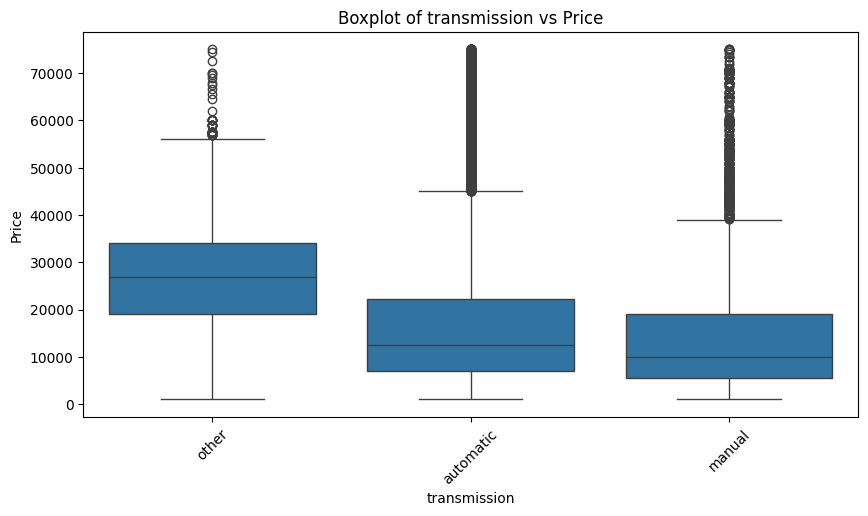

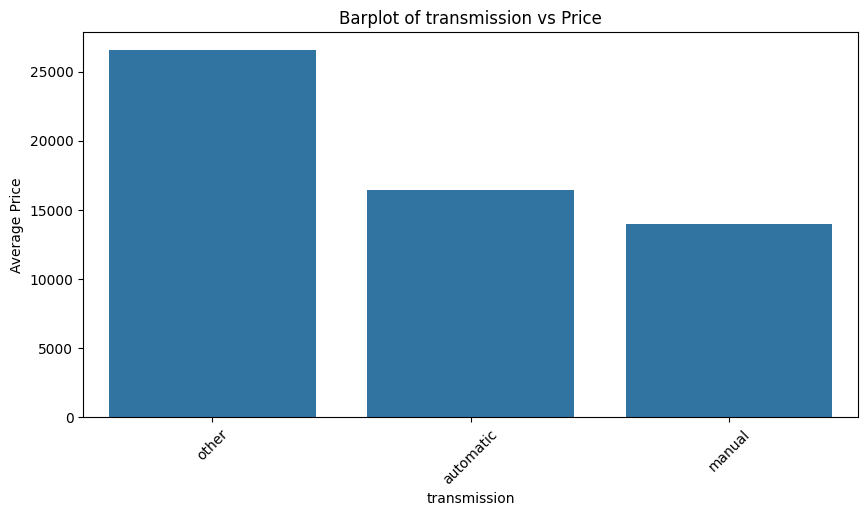

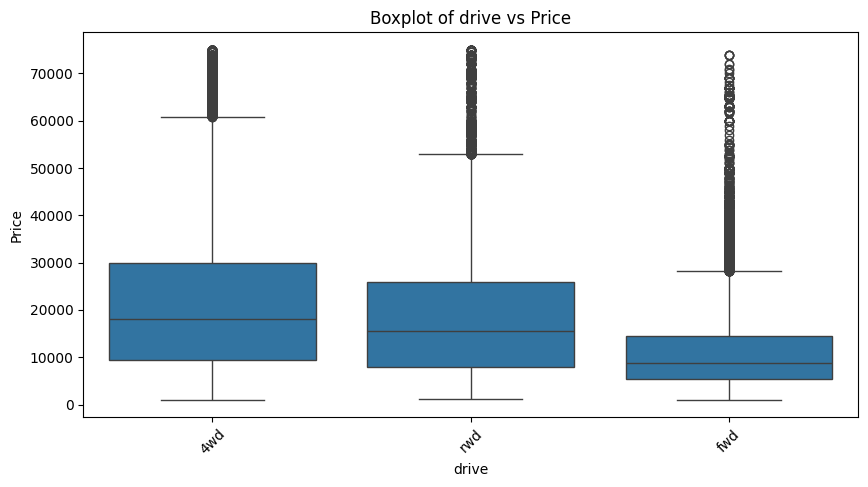

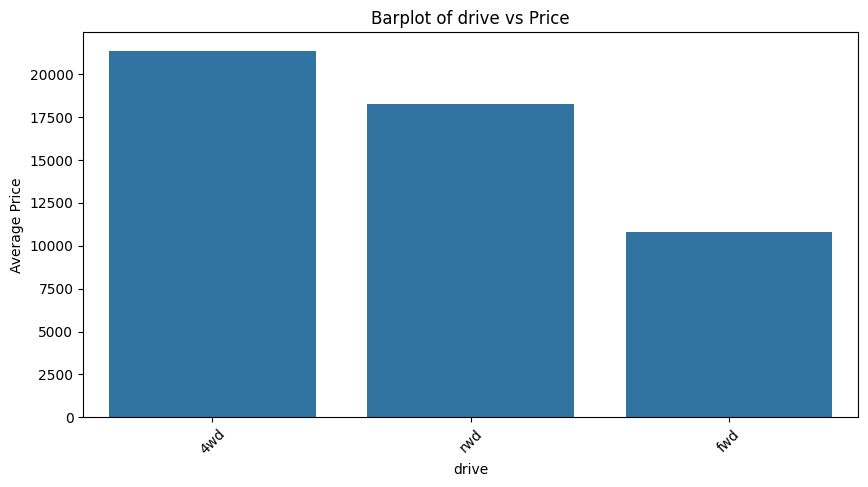

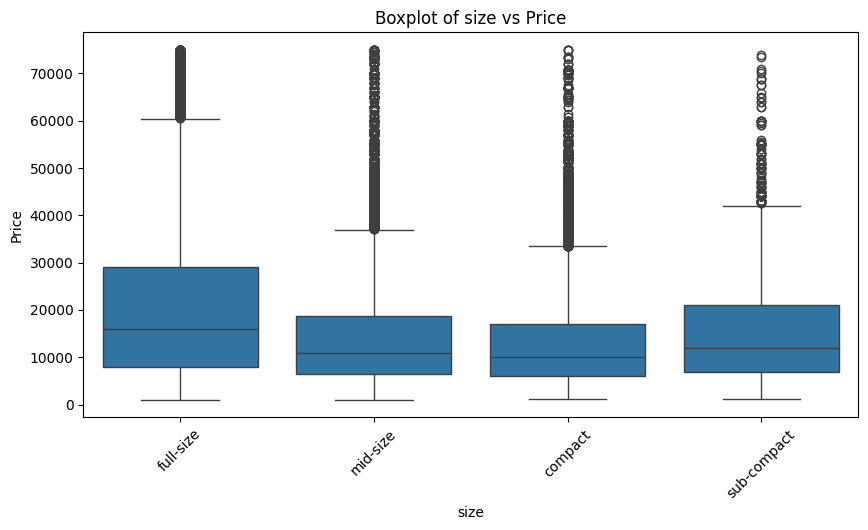

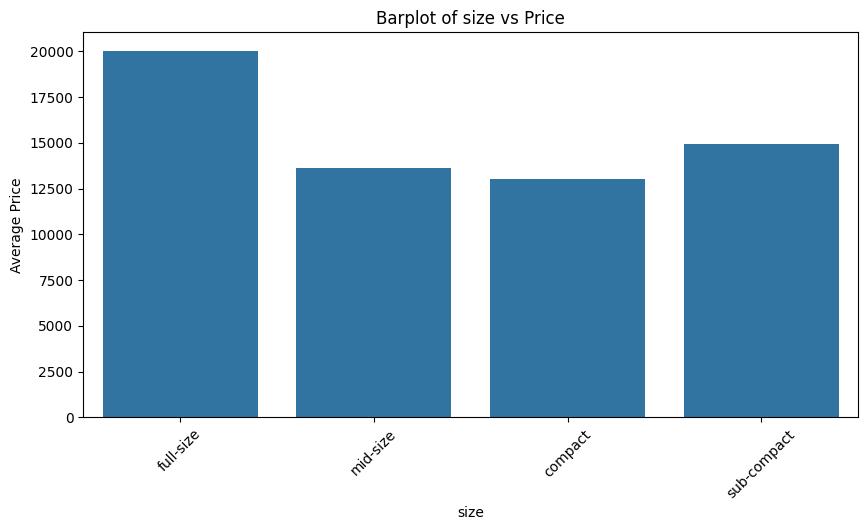

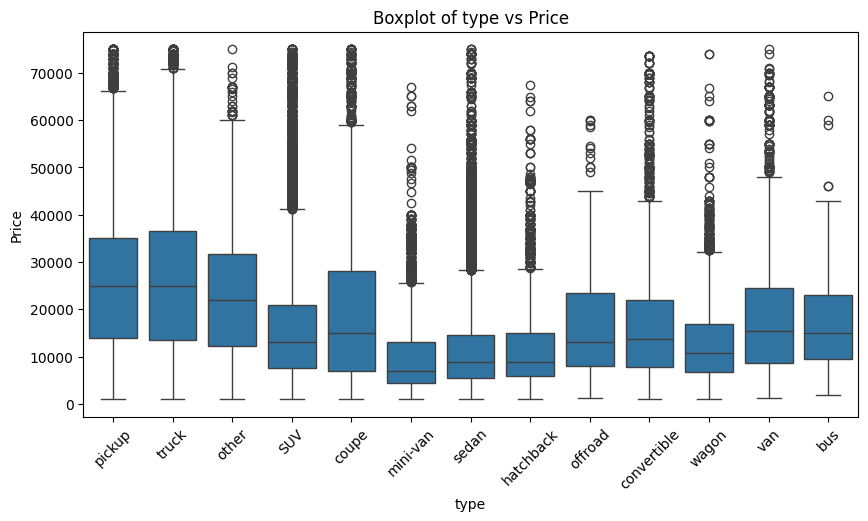

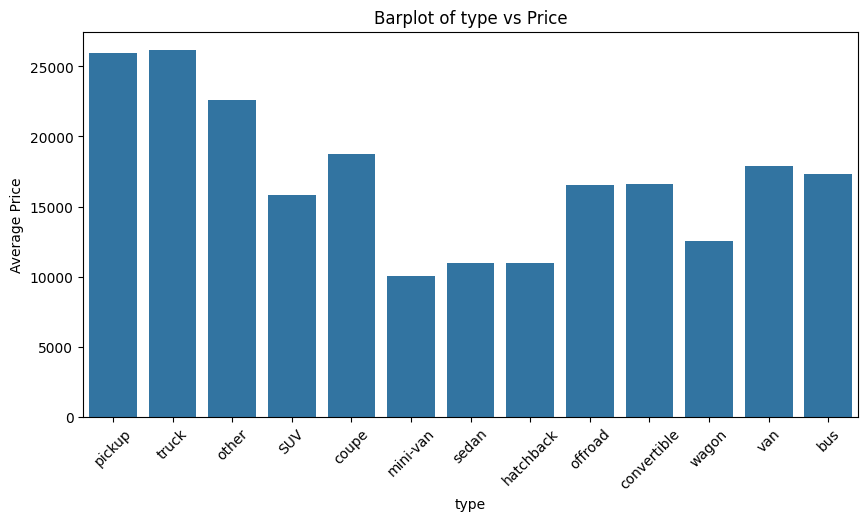

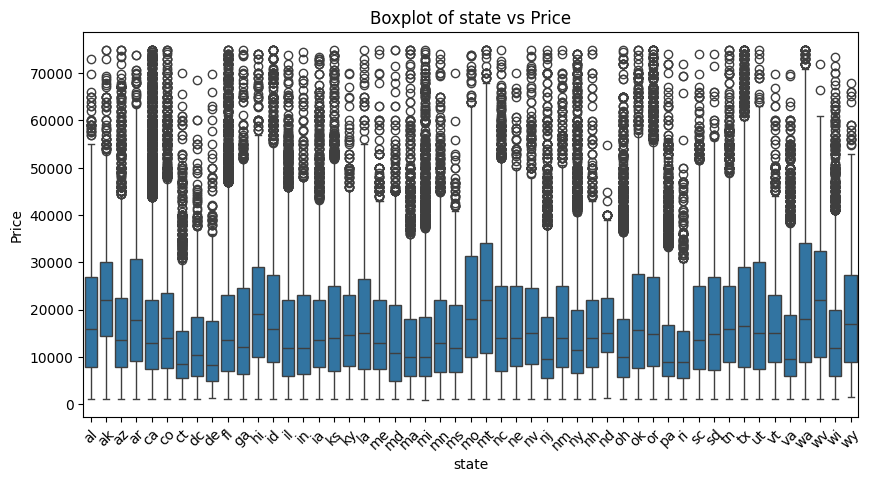

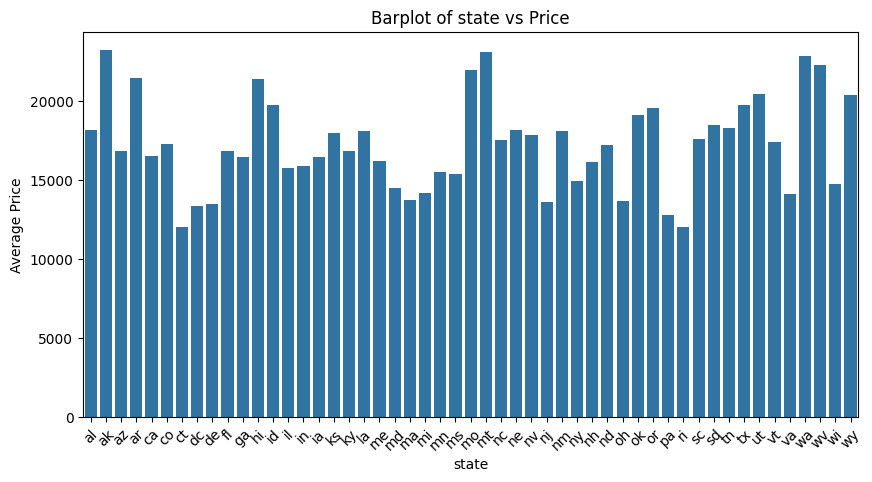

In [16]:
import numpy as np
# Bivariate Analysis - Categorical vs Target
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col], y=target)
    plt.title(f'Boxplot of {col} vs Price')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=df[col], y=target, estimator=np.mean, errorbar=None)
    plt.title(f'Barplot of {col} vs Price')
    plt.xlabel(col)
    plt.ylabel('Average Price')
    plt.xticks(rotation=45)
    plt.show()

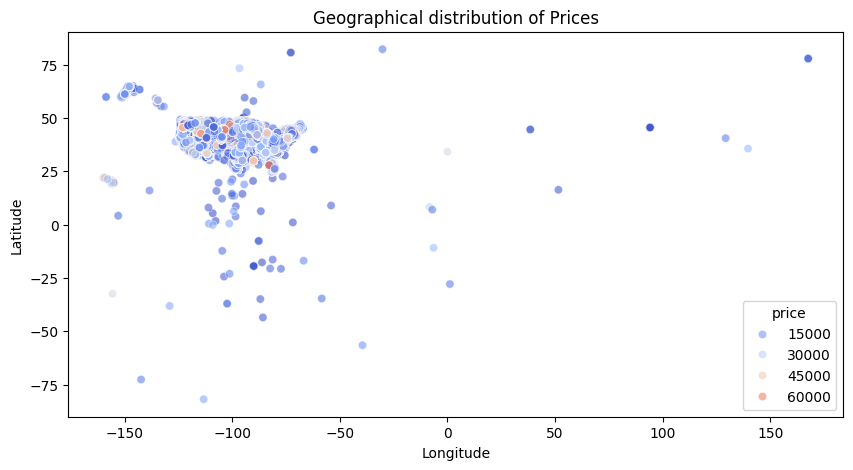

In [17]:
# Geographical Analysis - Latitude and Longitude
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["long"], y=df["lat"], hue=target, palette="coolwarm", alpha=0.6)
plt.title('Geographical distribution of Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [18]:
num_cols.remove("lat")
num_cols.remove("long")
print(num_cols)


['year', 'odometer']


In [19]:
print(cat_cols)

['manufacturer', 'model', 'fuel', 'transmission', 'drive', 'size', 'type', 'state']


In [20]:


X = df[num_cols + cat_cols]
y = df["price"]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocesador para columnas numéricas
numerical_transformer = MinMaxScaler()

# Preprocesador para columnas categóricas
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [21]:
# ColumnTransformer para aplicar los preprocesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

In [22]:
# Crear el pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])


In [23]:
# Entrenar el modelo
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['year', 'odometer']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['manufacturer', 'model',
                                                   'fuel', 'transmission',
                                                   'drive', 'size', 'type',
                                                   'state'])])),
                ('regressor', DecisionTreeRegressor(random_state=42))])

In [24]:
# Predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

In [25]:
# Calcular el error cuadrático medio (MSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

Root Mean Squared Error: 4672.449476561883


In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

R-squared: 0.8683806262266529


In [27]:
#random forest

model_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [28]:
# Entrenar el random forest
model_forest.fit(X_train, y_train)

In [ ]:
# Predicciones random forest en el conjunto de prueba
y_pred_forest = model_forest.predict(X_test)

In [ ]:
# Calcular el error cuadrático medio (MSE) random forrest
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)

print(f'Root Mean Squared Error random forest: {rmse_forest}')

In [ ]:
# Define the parameter grid for GridSearchCV or RandomizedSearchCV
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['auto', 'sqrt', 'log2']
}

# Initialize GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(estimator=model_forest, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
# Or, for RandomizedSearchCV
# random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42)


In [ ]:
# Fit the model using GridSearchCV or RandomizedSearchCV
grid_search.fit(X_train, y_train)
# Or, for RandomizedSearchCV
# random_search.fit(X_train, y_train)

In [ ]:
# Evaluate the best model
best_model_forest = grid_search.best_estimator_
# Or, for RandomizedSearchCV
# best_model = random_search.best_estimator_

In [ ]:
# Predict on the test set
y_pred_forest_best = best_model_forest.predict(X_test)

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred_forest_best)
print(f'Mean Squared Error: {mse:.2f}')
print(f'Best Parameters: {grid_search.best_params_}')

# Or, for RandomizedSearchCV
# print(f'Best Parameters: {random_search.best_params_}')